# Goals
- To examine the implementation & utilize the cost function for logistic regression

In [1]:
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt

In [2]:
def sigmoid(z):
    z = np.clip(z, -500, 500)
    g = 1.0 / (1.0 + np.exp(-z))

    return g

In [3]:
def plot_data(X, y, ax, pos_label = "y = 1", neg_label = "y = 0", s = 80, loc = 'best'):
    """Plots logistic data with two axes"""
    #finding indices of +ve and -ve examples
    pos = y == 1
    neg = y == 0
    pos = pos.reshape(-1, ) #work with 1D or 1D Vector
    ned = neg.reshape(-1, )

    #plotting examples
    ax.scatter(X[pos, 0], X[pos, 1],
        marker = 'x', s= s, 
               c = 'r', label = pos_label
    )
    ax.scatter(X[neg, 0], X[neg, 1],
        marker = 'o', s = s,
               label = neg_label, facecolors = 'none',
               edgecolor = 'b', lw = 3
    )
    ax.legend(loc = loc)
    ax.figure.toolbar_visible = False
    ax.figure.header_visible = False
    ax.figure.footer_visible = False

    plt.show()

# Dataset

In [4]:
X_train = np.array([[0.5, 1.5], [1, 1], [1.5, 0.5], [3, 0.5], [2, 2], [1, 2.5]])
y_train = np.array([0, 0, 0, 1, 1, 1])

# Plotting Data
- red crosses --> y = 1
- blue circles --> y = 0

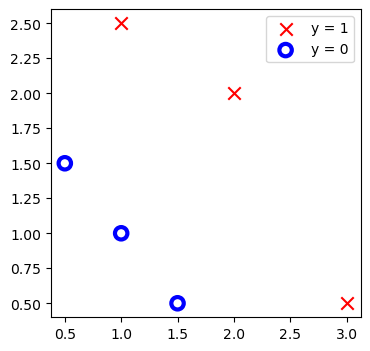

In [10]:
plt.close('all')
fig, ax = plt.subplots(1, 1, figsize = (4, 4))
plot_data(X_train, y_train, ax)

ax.axis([0, 4, 0, 4])
ax.set_xlabel(r"$x_0$", fontsize = 12)
ax.set_ylabel(r"$x_1$")
plt.show()

# Cost Function
For logistic regression, the cost function is of the form:

$$ J(\mathbf{w},b) = \frac{1}{m} \sum_{i=0}^{m-1} \left[ loss(f_{\mathbf{w},b}(\mathbf{x}^{(i)}), y^{(i)}) \right] \tag{1}$$

where, 
- $loss(f_{\mathbf{w},b}(\mathbf{x}^{(i)}), y^{(i)})$ is thecost of a single datapoint, which is:

$$loss(f_{\mathbf{w},b}(\mathbf{x}^{(i)}), y^{(i)}) = -y^{(i)} \log\left(f_{\mathbf{w},b}\left( \mathbf{x}^{(i)} \right) \right) - \left( 1 - y^{(i)}\right) \log \left( 1 - f_{\mathbf{w},b}\left( \mathbf{x}^{(i)} \right) \right) \tag{2}$$

- where, $m$ is the number of training examples in the dataset and:
$$
\begin{align}
  f_{\mathbf{w},b}(\mathbf{x^{(i)}}) &= g(z^{(i)})\tag{3} \\
  z^{(i)} &= \mathbf{w} \cdot \mathbf{x}^{(i)}+ b\tag{4} \\
  g(z^{(i)}) &= \frac{1}{1+e^{-z^{(i)}}}\tag{5} 
\end{align}
$$

The algorithm for *compute_cost_logistic* loops over all the examples, calculating the loss for each example and accumulating the total.

In [12]:
def compute_cost_logistic(X, y, w, b):
    """
    Compute cost
    Args:
        X (ndarray (m, n)): Data, m examples with n features
        y (ndarray (m, )): target values
        w (ndarray (n, )): model parameter
        b (scalar): model parameter
    Returns:
        cost (scalar): Cost
    """

    m = X.shape[0]
    cost = 0.0
    for i in range(m):
        z_i = np.dot(X[i], w) + b
        f_wb_i = sigmoid(z_i)
        cost += -y[i] * np.log(f_wb_i) - (1 - y[i]) * np.log(1 - f_wb_i)

    cost /= m
    return cost

In [13]:
#checking the implementation of cost
w_tmp = np.array([1, 1])
b_tmp = -3
print(compute_cost_logistic(X_train, y_train, w_tmp, b_tmp))

0.36686678640551745


# Example
Let's see the cost function output for different values
- For b = -3, $w_0$ = 1, $w_1$ = 1, plotting -3 + $w_0$ + $w_1$ = 0 (blue)
- For b = -4, $w_0$ = 1, $w_1$ = 1, plotting -4 + $w_0$ + $w_1$ = 0 (magenta)

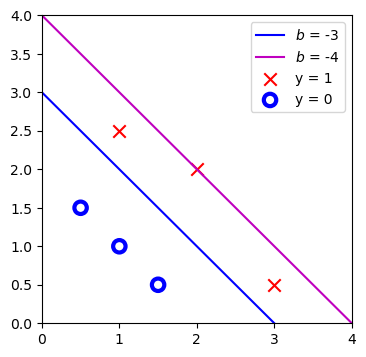

In [25]:
"""
x0 = np.arange(0, 6)
#plotting the two decision boundaries

x1 = 3 - x0
x1_ = 4 - x0
plt.close('all')

fig, ax = plt.subplots(1, 1, figsize = (4, 4))

#plotting decision boundary
ax.plot(x0, x1, c = 'b', label = "$b$ = -3")
ax.plot(x0, x1_, c = 'm', label = "$b$ = -4")
ax.axis([0, 4, 0, 4])

#plotting original data
plot_data(X_train, y_train, ax)
ax.axis([0, 4, 0, 4])
ax.set_ylabel("$x_1$")
ax.set_xlabel("$x_0$")
ax.legend(loc = 'upper right')
ax.title("Decision Boundary")
plt.show()
"""

x0 = np.arange(0, 6)
#plotting the two decision boundaries

x1 = 3 - x0
x1_ = 4 - x0
plt.close('all')

fig, ax = plt.subplots(1, 1, figsize = (4, 4))

#plotting decision boundary
ax.plot(x0, x1, c = 'b', label = "$b$ = -3")
ax.plot(x0, x1_, c = 'm', label = "$b$ = -4")
ax.axis([0, 4, 0, 4])

#plotting original data
plot_data(X_train, y_train, ax)
ax.axis([0, 4, 0, 4])
ax.set_ylabel("$x_1$")
ax.set_xlabel("$x_0$")

# Targeting the 'ax' object directly to prevent blank plots and warnings
ax.legend(loc = 'upper right')
ax.set_title("Decision Boundary")

plt.show()

In [22]:
#Checking cost for both cases
w_ = np.array([1, 1])
b1 = -3
b2 = -4

print("Cost for b = -3: ", compute_cost_logistic(X_train, y_train, w_, b1))
print("Cost for b = -4: ", compute_cost_logistic(X_train, y_train, w_, b2))

Cost for b = -3:  0.36686678640551745
Cost for b = -4:  0.5036808636748461
